In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from rwmcmc.targets import gaussian_1d_log_pdf
from rwmcmc.samplers import random_walk_metropolis_hastings

In [3]:
samples, accepted = random_walk_metropolis_hastings(
    target_log_pdf=gaussian_1d_log_pdf,
    x0=0.0,
    n_samples=100000,
    step_size=2.0,
)

print(f"Number of samples: {len(samples)}\n")
print(f"Acceptance rate: {accepted.mean():.3f}")
print(f"Sample mean:     {samples.mean():.4f}  (true: 0.0000)")
print(f"Sample std:      {samples.std():.4f}  (true: 1.0000)")

Number of samples: 100000

Acceptance rate: 0.499
Sample mean:     -0.0045  (true: 0.0000)
Sample std:      1.0007  (true: 1.0000)


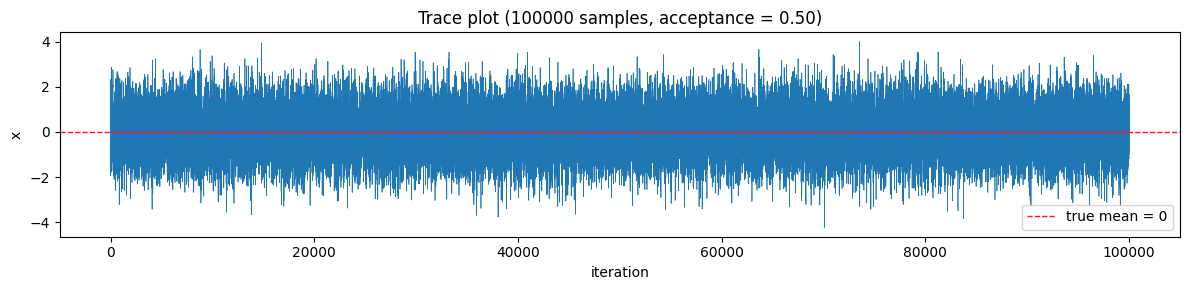

In [4]:
fig, ax = plt.subplots( figsize=(12, 3))
ax.plot(samples, linewidth=0.5, color="C0")
ax.axhline(0, color="C3", linestyle="--", linewidth=1, label="true mean = 0")
ax.set_xlabel("iteration")
ax.set_ylabel("x")
ax.set_title(f"Trace plot ({len(samples)} samples, acceptance = {accepted.mean():.2f})")
ax.legend()

plt.tight_layout()
plt.show()

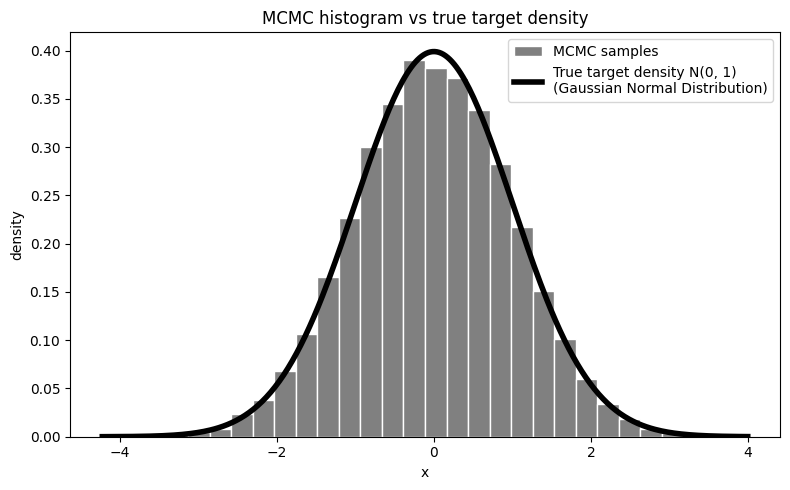

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(samples, bins=30, density=True , alpha=1, color="grey", 
        edgecolor="white", label="MCMC samples")
#density = True to plot the histogram as a density, not counts

x_grid = np.linspace(samples.min(), samples.max(), 300)
ax.plot(x_grid, norm.pdf(x_grid), color="black", linewidth=4,
        label="True target density N(0, 1)\n(Gaussian Normal Distribution)")

ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("MCMC histogram vs true target density")
ax.legend()
plt.tight_layout()
plt.show()

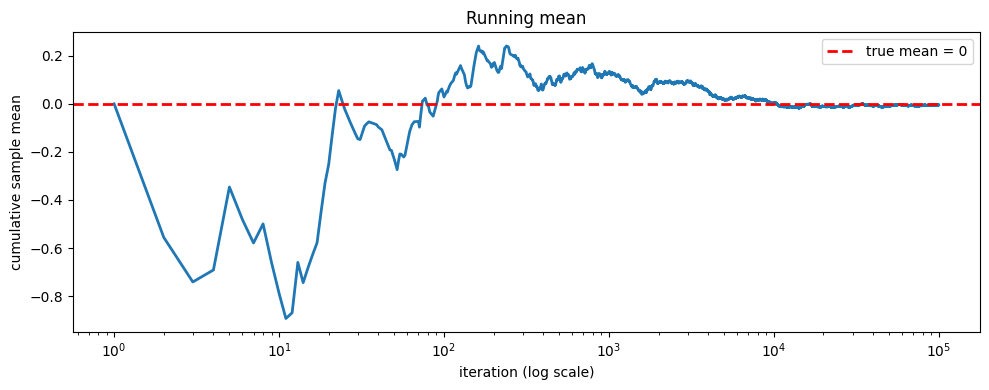

In [6]:
mean_every_instant = np.cumsum(samples) / np.arange(1, len(samples) + 1)
# Large number of samples is needed to get close to the true mean (0) due to the high variance of the samples

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(samples) + 1), mean_every_instant, linewidth=2)
ax.axhline(0, color="r", linestyle="--", linewidth=2, label="true mean = 0")
ax.set_xlabel("iteration (log scale)")
ax.set_ylabel("cumulative sample mean")
ax.set_title("Running mean")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()